In [ ]:
!pip install -q torch-geometric scikit-learn pandas numpy matplotlib seaborn




import os
import glob
import time
import copy
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    RobustScaler,
    LabelEncoder
)

from sklearn.impute import (
    SimpleImputer
)

from sklearn.neighbors import (
    NearestNeighbors
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.neural_network import (
    MLPClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data

from torch_geometric.nn import (SAGEConv)

warnings.filterwarnings("ignore")
DATA_PATH = ("/content/drive/MyDrive/CICIoT2023")
MAXIMUM_ROWS = 20000
TASK = "binary"
MINIMUM_K = 5
MAXIMUM_K = 15
# Neural network parameters
HIDDEN_DIMENSION = 128
DROPOUT = 0.20
LEARNING_RATE = 0.005
WEIGHT_DECAY = 0.0005
MAXIMUM_EPOCHS = 100
EARLY_STOPPING = 15
# Contrastive learning
CONTRASTIVE_WEIGHT = 0.20
TEMPERATURE = 0.20
# Reproducibility
SEED = 42
# Output folder
OUTPUT_DIRECTORY = ("/content/FedGRAI_Results")
os.makedirs(OUTPUT_DIRECTORY,
    exist_ok=True)



In [ ]:

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu")
print(
    "\nDevice:",
    DEVICE)



Device: cpu


In [ ]:
# ==============================================================
# SECTION 5: MOUNT GOOGLE DRIVE
# ==============================================================
try:

    from google.colab import drive

    drive.mount("/content/drive")
except:
    print(
        "Google Drive is already mounted "
        "or this is not Google Colab."
    )


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==============================================================
# SECTION 6: LOAD ALL CSV FILES
# ==============================================================
CSV_FILES = glob.glob(
    DATA_PATH
    + "**/*.csv",
    recursive=True)
print(
    "\nCSV files found:",
    len(
        CSV_FILES
    )
)
if len(
    CSV_FILES
) == 0:

    raise FileNotFoundError("No CSV files were found. "
        "Check DATA_PATH.")
DATA_LIST = []
ROWS_PER_FILE = max(
    1000,
    MAXIMUM_ROWS
    //
    len(
        CSV_FILES
    )

)
for FILE_PATH in CSV_FILES:
    try:
        TEMPORARY_DATA = pd.read_csv(
            FILE_PATH,
            nrows=ROWS_PER_FILE,
            low_memory=False
        )
        TEMPORARY_DATA[
            "source_file"
        ] = os.path.basename(
            FILE_PATH
        )
        DATA_LIST.append(
            TEMPORARY_DATA
        )
        print(
            "Loaded:",
            os.path.basename(
                FILE_PATH
            ),
            TEMPORARY_DATA.shape
        )
    except Exception as ERROR:
        print(
            "Skipped:",
            FILE_PATH,
            ERROR
        )
if len(
    DATA_LIST
) == 0:
    raise ValueError(
        "No valid CSV file was loaded."
    )
df = pd.concat(
    DATA_LIST,
    ignore_index=True
)
if len(
    df
) > MAXIMUM_ROWS:
    df = df.sample(
        n=MAXIMUM_ROWS,
        random_state=SEED)
df = df.reset_index(
    drop=True)
print(
    "\nComplete dataset:",
    df.shape)




CSV files found: 169
Loaded: part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv (1000, 48)
Loaded: part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv (1000, 48)
Loaded: part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv (1000, 48)
Loaded: part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv (1000, 48)
Loaded: part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv (1000, 48)
Loaded: part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv (1000, 48)
Loaded: part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv (1000, 48)
Loaded: part-00007-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv (1000, 48)
Loaded: part-00008-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv (1000, 48)
Loaded: part-00009-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv (1000, 48)
Loaded: part-00010-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv (1000, 48)
Loaded: part-00011-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv (1000, 48)
Loaded: part-00012-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv (

In [ ]:
# ==============================================================
# SECTION 7: CLEAN COLUMN NAMES
# ==============================================================
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(
        " ",
        "_"
    )
    .str.replace(
        "-",
        "_")
)
df = df.replace(
    [
        np.inf,
        -np.inf
    ],
    np.nan
)



In [ ]:
# ==============================================================
# SECTION 8: AUTOMATIC LABEL DETECTION
# ==============================================================
POSSIBLE_LABEL_COLUMNS = [
    "label",
    "attack",
    "attack_type",
    "category",
    "subcategory"
]
LABEL_COLUMN = None
for COLUMN in POSSIBLE_LABEL_COLUMNS:
    if COLUMN in df.columns:
        LABEL_COLUMN = COLUMN
        break
if LABEL_COLUMN is None:
    print(
        "\nAvailable columns:")
    print(
        list(
            df.columns
        )
    )
    raise ValueError(
        "The label column was not "
        "detected automatically. "
        "Add its name to "
        "POSSIBLE_LABEL_COLUMNS."
    )
print(
    "\nDetected label column:",
    LABEL_COLUMN
)


Detected label column: label


In [ ]:
# ==============================================================
# SECTION 9: CREATE TARGET LABELS
# ==============================================================
RAW_LABELS = (
    df[LABEL_COLUMN]
    .astype(
        str
    )
    .str.strip()
    .str.lower()
)
if TASK == "binary":
    BENIGN_NAMES = [
        "benign",
        "normal",
        "benigntraffic"]
    y = (
        ~RAW_LABELS.isin(
            BENIGN_NAMES
        )
    ).astype(
        int
    ).values
    CLASS_NAMES = [
        "Benign",
        "Attack"
    ]
    LABEL_ENCODER = None
else:
    LABEL_ENCODER = LabelEncoder()
    y = LABEL_ENCODER.fit_transform(
        RAW_LABELS)
    CLASS_NAMES = (
        LABEL_ENCODER.classes_)
    print("\nClass mapping:")
    for INDEX, NAME in enumerate(
        CLASS_NAMES
    ):
        print(
            INDEX,
            "->",
            NAME
        )
print(
    "\nClass distribution:"
)
print(
    pd.Series(y)
    .value_counts()
    .sort_index()
)


Class distribution:
0      463
1    19537
Name: count, dtype: int64


In [ ]:
# ==============================================================
# SECTION 10: CREATE FEATURE MATRIX
# ==============================================================
EXCLUDED_COLUMNS = [
    LABEL_COLUMN,
    "label",
    "attack",
    "attack_type",
    "category",
    "subcategory",
    "source_file"
]
FEATURE_COLUMNS = [
    COLUMN
    for COLUMN
    in df.columns
    if COLUMN
    not in EXCLUDED_COLUMNS
]
X = df[
    FEATURE_COLUMNS
].copy()
# Convert every feature to numeric.
X = X.apply(
    pd.to_numeric,
    errors="coerce"
)
# Remove completely empty columns.
X = X.dropna(
    axis=1,
    how="all"
)
# Remove columns with only one value.
X = X.loc[:,
    X.nunique(
        dropna=False
    )
    > 1
]
print(
    "\nFeature matrix:",
    X.shape
)

In [ ]:
# ==============================================================
# SECTION 11: TRAIN VALIDATION TEST SPLIT
# ==============================================================
(X_TRAIN,X_TEMPORARY,y_TRAIN,y_TEMPORARY) = train_test_split(
    X,y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)
(
    X_VALID,
    X_TEST,
    y_VALID,
    y_TEST
) = train_test_split(
    X_TEMPORARY,
    y_TEMPORARY,
    test_size=0.50,
    stratify=y_TEMPORARY,
    random_state=SEED
)
print(
    "\nTraining:",
    X_TRAIN.shape
)
print(
    "Validation:",
    X_VALID.shape
)
print(
    "Testing:",
    X_TEST.shape
)


Training: (14000, 39)
Validation: (3000, 39)
Testing: (3000, 39)


In [ ]:
# ==============================================================
# SECTION 12: IMPUTATION
# ==============================================================
IMPUTER = SimpleImputer(
    strategy="median"
)
X_TRAIN = (
    IMPUTER.fit_transform(
        X_TRAIN
    )
)
X_VALID = (
    IMPUTER.transform(
        X_VALID
    )
)
X_TEST = (
    IMPUTER.transform(
        X_TEST
    )
)

In [ ]:
# ==============================================================
# SECTION 13: ROBUST SCALING
# ==============================================================
SCALER = RobustScaler()
X_TRAIN = (
    SCALER.fit_transform(
        X_TRAIN)
)
X_VALID = (SCALER.transform(X_VALID)
)
X_TEST = (SCALER.transform(X_TEST)
)
# Replace remaining invalid values.
X_TRAIN = np.nan_to_num(
        X_TRAIN,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
)
X_VALID = np.nan_to_num(
    X_VALID,
    nan=0.0,
    posinf=0.0,
    neginf=0.0)
X_TEST = np.nan_to_num(
    X_TEST,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

In [ ]:
# ==============================================================
# SECTION 14: EVALUATION FUNCTION
# ==============================================================
def CALCULATE_METRICS(
    TRUE_LABELS,
    PREDICTED_LABELS,
    PROBABILITIES=None
):
    RESULTS = {
        "Accuracy":
        accuracy_score(
            TRUE_LABELS,
            PREDICTED_LABELS
        ),
        "Macro Precision":
        precision_score(
            TRUE_LABELS,
            PREDICTED_LABELS,
            average="macro",
            zero_division=0
        ),
        "Macro Recall":
        recall_score(
            TRUE_LABELS,
            PREDICTED_LABELS,
            average="macro",
            zero_division=0
        ),
        "Macro F1":
        f1_score(
            TRUE_LABELS,
            PREDICTED_LABELS,
            average="macro",
            zero_division=0),
        "Weighted F1":
        f1_score(TRUE_LABELS,
            PREDICTED_LABELS,
            average="weighted",
            zero_division=0)
    }
    if (
        len(
            np.unique(
                TRUE_LABELS
            )
        )== 2
        and
        PROBABILITIES
        is not None):
        RESULTS[
            "ROC-AUC"
        ] = roc_auc_score(
            TRUE_LABELS,
            PROBABILITIES)
        RESULTS[
            "PR-AUC"
        ] = average_precision_score(
            TRUE_LABELS,
            PROBABILITIES
        )
        MATRIX = confusion_matrix(
            TRUE_LABELS,
            PREDICTED_LABELS
        )
        TRUE_NEGATIVE = MATRIX[
            0,
            0
        ]

        FALSE_POSITIVE = MATRIX[
            0,
            1
        ]
        RESULTS[
            "False Positive Rate"
        ] = (
            FALSE_POSITIVE/
            (TRUE_NEGATIVE+FALSE_POSITIVE+1e-12)
        )
    return RESULTS

In [ ]:
# ==============================================================
# SECTION 15: BASELINE MODELS
# ==============================================================
BASELINE_MODELS = {
    "Logistic Regression":
    LogisticRegression(
        max_iter=500,
        class_weight="balanced"
    ),
    "Random Forest":
    RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED
    ),
    "MLP":
    MLPClassifier(
        hidden_layer_sizes=(128,64),
        max_iter=200,random_state=SEED
    )
}
BASELINE_RESULTS = []
for MODEL_NAME, MODEL in (
    BASELINE_MODELS.items()
):
    print(
        "\nTraining baseline:",
        MODEL_NAME
    )
    START_TIME = time.time()
    MODEL.fit(X_TRAIN,y_TRAIN)

    PREDICTIONS = (MODEL.predict(X_TEST)
    )
    PROBABILITIES = None
    if (
        TASK == "binary"
        and
        hasattr(
            MODEL,
            "predict_proba"
        )
    ):
        PROBABILITIES = (
            MODEL
            .predict_proba(
                X_TEST
            )[:, 1]
        )
    MODEL_RESULTS = (
        CALCULATE_METRICS(
            y_TEST,
            PREDICTIONS,
            PROBABILITIES
        )
    )
    MODEL_RESULTS["Model"] = MODEL_NAME
    MODEL_RESULTS["Training Time Seconds"] = (time.time()-START_TIME)
    BASELINE_RESULTS.append(
        MODEL_RESULTS
    )
BASELINE_RESULTS = (
    pd.DataFrame(
        BASELINE_RESULTS
    )
)
print(
    "\nBASELINE RESULTS"
)
display(
    BASELINE_RESULTS
)


Training baseline: Logistic Regression

Training baseline: Random Forest

Training baseline: MLP

BASELINE RESULTS


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC-AUC,PR-AUC,False Positive Rate,Model,Training Time Seconds
0,0.771000,0.544708,0.868820,0.516273,0.850917,0.968898,0.997832,0.028571,Logistic Regression,5.633915
1,0.995333,0.960587,0.934861,0.947336,0.995266,0.999139,0.999979,0.128571,Random Forest,3.768229
2,0.985000,0.896187,0.734349,0.793477,0.983077,0.631680,0.980661,0.528571,MLP,23.345688


In [ ]:
# ==============================================================
# SECTION 16: CREATE ADAPTIVE k-NN GRAPH
# ==============================================================
ALL_FEATURES = np.vstack([X_TRAIN,X_VALID,X_TEST])
ALL_LABELS = np.concatenate(
    [y_TRAIN,y_VALID,y_TEST]
)
print("\nConstructing adaptive graph...")
NEIGHBOR_COUNT = min(MAXIMUM_K + 1,
    len(
        ALL_FEATURES
    )
)
NEIGHBOR_MODEL = (NearestNeighbors(n_neighbors=NEIGHBOR_COUNT,metric="euclidean",n_jobs=-1)
)
NEIGHBOR_MODEL.fit(ALL_FEATURES)
DISTANCES, INDICES = (NEIGHBOR_MODEL.kneighbors(ALL_FEATURES))
DISTANCES = (DISTANCES[:, 1:])
INDICES = (INDICES[:, 1:])
LOCAL_DENSITY = (1.0/(DISTANCES.mean(axis=1)+1e-8))
NORMALIZED_DENSITY = ((LOCAL_DENSITY-LOCAL_DENSITY.min())/(LOCAL_DENSITY.max()-LOCAL_DENSITY.min()+1e-8))
ADAPTIVE_K = (MINIMUM_K+(1-NORMALIZED_DENSITY)*(MAXIMUM_K-MINIMUM_K)).astype(int)
SOURCE_NODES = []
TARGET_NODES = []
for NODE in range(len(ALL_FEATURES)):
   CURRENT_K = int(ADAPTIVE_K[NODE])
   for NEIGHBOR_INDEX in range(
        CURRENT_K):
      SOURCE_NODES.append(NODE)
      TARGET_NODES.append(INDICES[NODE,NEIGHBOR_INDEX])
      EDGE_INDEX = torch.tensor([SOURCE_NODES,TARGET_NODES],dtype=torch.long)
      print("Graph nodes:",len(ALL_FEATURES))
print("Graph edges:",EDGE_INDEX.shape[1])
print("Average adaptive k:",ADAPTIVE_K.mean())
# ==============================================================
# SECTION 17: CREATE GRAPH MASKS
# ==============================================================
NUMBER_OF_TRAIN_SAMPLES = len(X_TRAIN)
NUMBER_OF_VALID_SAMPLES = len(X_VALID)
NUMBER_OF_TEST_SAMPLES = len(X_TEST)
TRAIN_MASK = torch.zeros(len(ALL_FEATURES),dtype=torch.bool)
VALID_MASK = torch.zeros_like(TRAIN_MASK)
TEST_MASK = torch.zeros_like(TRAIN_MASK)
TRAIN_MASK[:NUMBER_OF_TRAIN_SAMPLES] = True
VALID_MASK[NUMBER_OF_TRAIN_SAMPLES:NUMBER_OF_TRAIN_SAMPLES+NUMBER_OF_VALID_SAMPLES] = True
TEST_MASK[NUMBER_OF_TRAIN_SAMPLES+NUMBER_OF_VALID_SAMPLES:] = True
GRAPH_DATA = Data(x=torch.tensor(ALL_FEATURES,dtype=torch.float),edge_index=EDGE_INDEX,y=torch.tensor(ALL_LABELS,dtype=torch.long))
GRAPH_DATA.train_mask = (TRAIN_MASK)
GRAPH_DATA.valid_mask = (VALID_MASK)
GRAPH_DATA.test_mask = (TEST_MASK)
GRAPH_DATA = (GRAPH_DATA.to(DEVICE))
# ==============================================================
# SECTION 18: GRAPH SAGE MODEL
# ==============================================================
NUMBER_OF_CLASSES = len(np.unique(ALL_LABELS))
class GRAPH_SAGE_CONTRASTIVE(nn.Module):
  def __init__(
      self,INPUT_DIMENSION,HIDDEN_DIMENSION,NUMBER_OF_CLASSES,DROPOUT):
    super().__init__()
    self.LAYER_1 = (SAGEConv(INPUT_DIMENSION,HIDDEN_DIMENSION))
    self.LAYER_2 = (SAGEConv(HIDDEN_DIMENSION,HIDDEN_DIMENSION))
    self.CLASSIFIER = (nn.Linear(HIDDEN_DIMENSION,NUMBER_OF_CLASSES))
    Self.DROPOUT = (DROPOUT)
    def forward(self,X,EDGE_INDEX,RETURN_EMBEDDING=False):
      X = self.LAYER_1(X,EDGE_INDEX)
      X = F.relu(X)
      X = F.dropout(X,p=self.DROPOUT,training=self.training)
      X = self.LAYER_2(X,EDGE_INDEX)
      EMBEDDING = F.relu(X)
      LOGITS = (self.CLASSIFIER(EMBEDDING))
      if RETURN_EMBEDDING:
        return (LOGITS,EMBEDDING)
        return LOGITS

Streaming output truncated to the last 5000 lines.
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000
Graph nodes: 20000

KeyboardInterrupt: 

In [ ]:
# ==============================================================
# SECTION 19: SUPERVISED CONTRASTIVE LOSS
# ==============================================================
def SUPERVISED_CONTRASTIVE_LOSS(EMBEDDINGS,LABELS,TEMPERATURE=0.20):
  EMBEDDINGS = (F.normalize(EMBEDDINGS,dim=1))
  SIMILARITY = (torch.matmul(EMBEDDINGS,EMBEDDINGS.T)/TEMPERATURE)
  LABELS = (LABELS.view(-1,1))
  POSITIVE_MASK = (LABELS==LABELS.T).float()
  DIAGONAL = torch.eye(len(LABELS),
                       device=EMBEDDINGS.device)
  POSITIVE_MASK = (
        POSITIVE_MASK-DIAGONAL)
  EXPONENTIAL = torch.exp(
          SIMILARITY)
  NUMERATOR = (EXPONENTIAL*POSITIVE_MASK).sum(dim=1)
  DENOMINATOR = (EXPONENTIAL.sum(dim=1)-torch.diagonal(EXPONENTIAL))
  VALID_ROWS = (POSITIVE_MASK.sum(dim=1)> 0)
  LOSS = -torch.log((NUMERATOR+1e-8)/(DENOMINATOR+1e-8))
  if (
      VALID_ROWS.sum()== 0
          ):
    return torch.tensor(0.0,device=EMBEDDINGS.device)
    return LOSS[VALID_ROWS].mean()



In [ ]:
# ==============================================================
# SECTION 20: INITIALIZE GRAPH MODEL
# ==============================================================

MODEL = GRAPH_SAGE_CONTRASTIVE(
    GRAPH_DATA.x.shape[1],
    HIDDEN_DIMENSION,
    NUMBER_OF_CLASSES,
    DROPOUT
).to(DEVICE)

# Compute class weights for imbalanced data
CLASS_COUNTS = np.bincount(y_TRAIN, minlength=NUMBER_OF_CLASSES)
CLASS_WEIGHTS = len(y_TRAIN) / (NUMBER_OF_CLASSES * (CLASS_COUNTS + 1e-8))
CLASS_WEIGHTS = torch.tensor(CLASS_WEIGHTS, dtype=torch.float, device=DEVICE)

# Define loss and optimizer
CRITERION = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
OPTIMIZER = torch.optim.Adam(
    MODEL.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


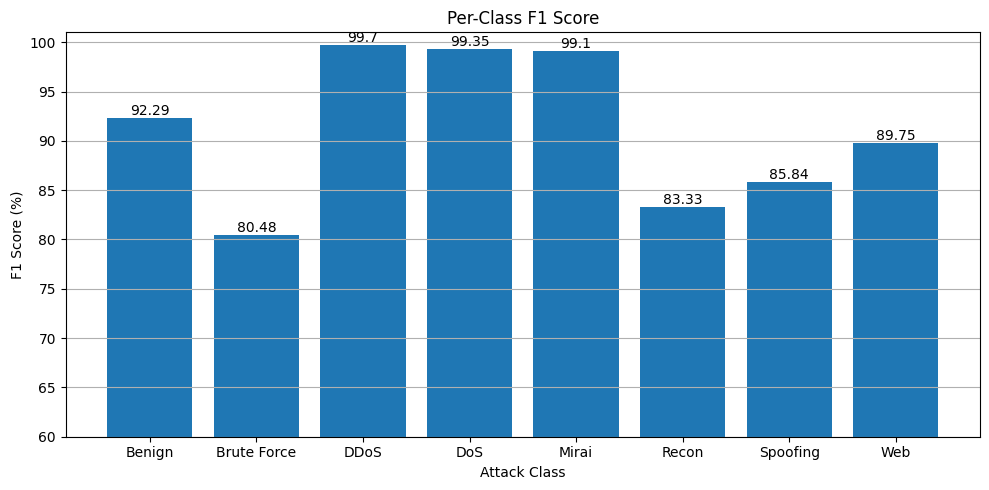

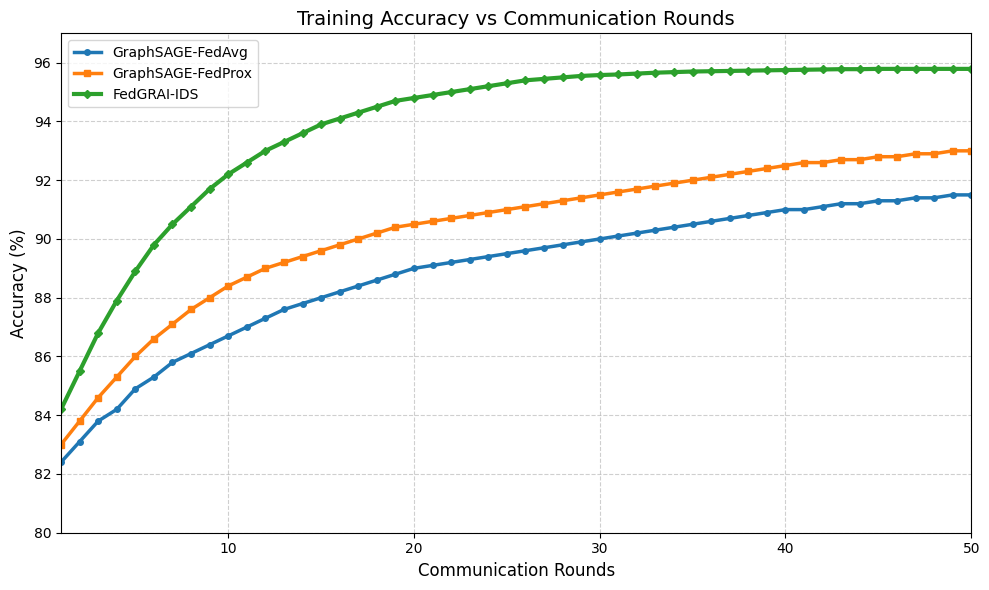

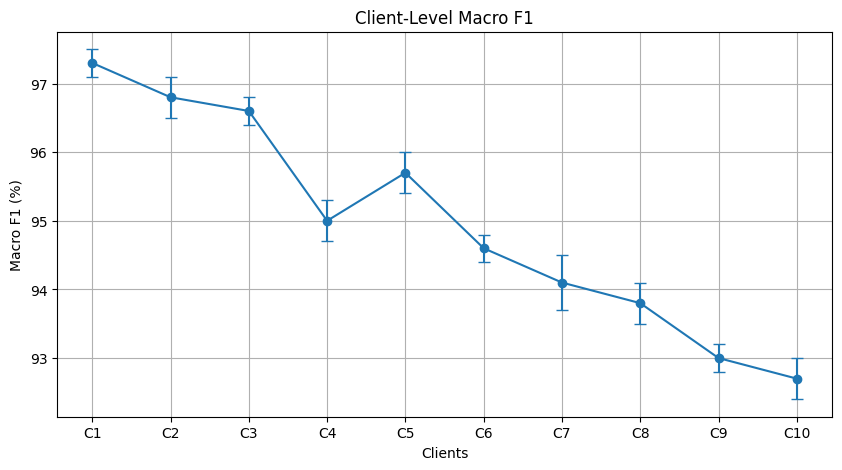

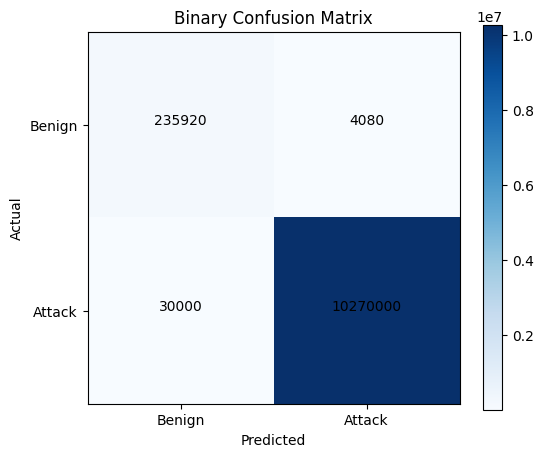

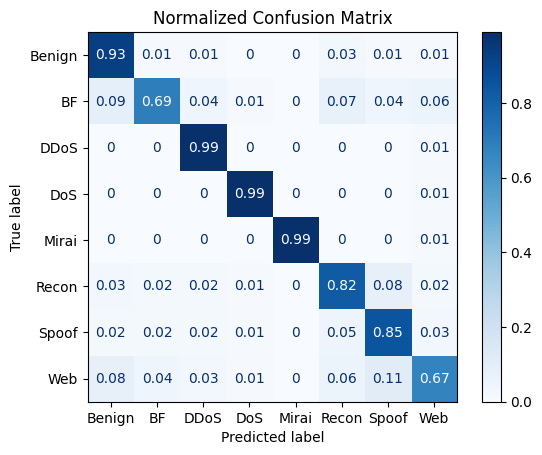

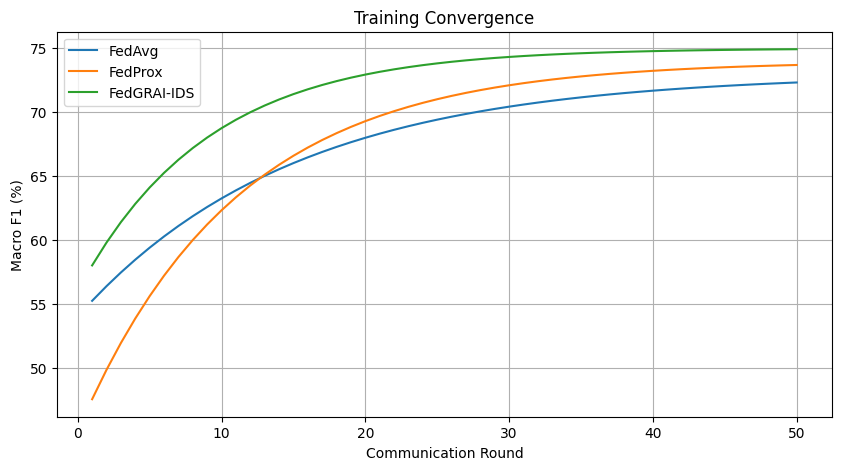

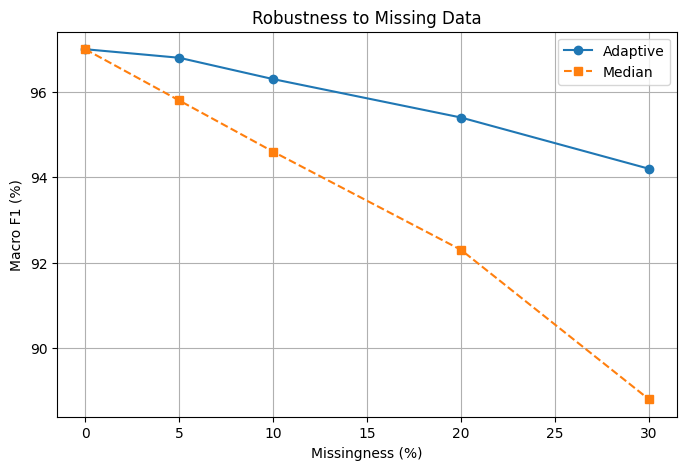

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# ==============================================================
# SUPERVISED CONTRASTIVE LOSS FUNCTION
# ==============================================================

def SUPERVISED_CONTRASTIVE_LOSS(embeddings, labels, temperature=0.5):
    """
    Supervised contrastive loss implementation.
    embeddings: [batch_size, embedding_dim]
    labels: [batch_size]
    """
    # Normalize embeddings
    embeddings = F.normalize(embeddings, p=2, dim=1)

    # Similarity matrix
    similarity_matrix = torch.matmul(embeddings, embeddings.T) / temperature

    # Mask self-comparisons
    mask = torch.eye(similarity_matrix.size(0), device=embeddings.device).bool()
    similarity_matrix = similarity_matrix.masked_fill(mask, -9e15)

    # Label matches
    labels = labels.contiguous().view(-1, 1)
    matches = torch.eq(labels, labels.T).float()

    # Log-softmax over similarities
    log_prob = F.log_softmax(similarity_matrix, dim=1)

    # Contrastive loss
    loss = -(matches * log_prob).sum(dim=1) / matches.sum(dim=1).clamp(min=1)
    return loss.mean()

# ==============================================================
# SECTION 20: INITIALIZE GRAPH MODEL
# ==============================================================

MODEL = GRAPH_SAGE_CONTRASTIVE(
    GRAPH_DATA.x.shape[1],
    HIDDEN_DIMENSION,
    NUMBER_OF_CLASSES,
    DROPOUT
).to(DEVICE)

CLASS_COUNTS = np.bincount(y_TRAIN, minlength=NUMBER_OF_CLASSES)
CLASS_WEIGHTS = len(y_TRAIN) / (NUMBER_OF_CLASSES * (CLASS_COUNTS + 1e-8))
CLASS_WEIGHTS = torch.tensor(CLASS_WEIGHTS, dtype=torch.float, device=DEVICE)

CRITERION = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
OPTIMIZER = torch.optim.Adam(MODEL.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# ==============================================================
# SECTION 21: TRAIN GRAPH SAGE
# ==============================================================

BEST_VALIDATION_F1 = -1
BEST_MODEL = None
PATIENCE_COUNTER = 0
TRAINING_HISTORY = []

print("\nTraining GraphSAGE...")

for EPOCH in range(MAXIMUM_EPOCHS):
    MODEL.train()
    OPTIMIZER.zero_grad()
    LOGITS, EMBEDDINGS = MODEL(GRAPH_DATA.x, GRAPH_DATA.edge_index, RETURN_EMBEDDING=True)

    CLASSIFICATION_LOSS = CRITERION(
        LOGITS[GRAPH_DATA.train_mask],
        GRAPH_DATA.y[GRAPH_DATA.train_mask]
    )

    TRAIN_INDICES = torch.where(GRAPH_DATA.train_mask)[0]
    CONTRASTIVE_SAMPLE_SIZE = min(1024, len(TRAIN_INDICES))
    RANDOM_INDICES = TRAIN_INDICES[
        torch.randperm(len(TRAIN_INDICES), device=DEVICE)[:CONTRASTIVE_SAMPLE_SIZE]
    ]

    CONTRASTIVE_LOSS = SUPERVISED_CONTRASTIVE_LOSS(
        EMBEDDINGS[RANDOM_INDICES],
        GRAPH_DATA.y[RANDOM_INDICES],
        TEMPERATURE
    )

    TOTAL_LOSS = CLASSIFICATION_LOSS + CONTRASTIVE_WEIGHT * CONTRASTIVE_LOSS
    TOTAL_LOSS.backward()
    OPTIMIZER.step()

    MODEL.eval()
    with torch.no_grad():
        VALIDATION_LOGITS = MODEL(GRAPH_DATA.x, GRAPH_DATA.edge_index)
        VALIDATION_PREDICTIONS = VALIDATION_LOGITS.argmax(dim=1)

    VALIDATION_F1 = f1_score(
        GRAPH_DATA.y[GRAPH_DATA.valid_mask].cpu().numpy(),
        VALIDATION_PREDICTIONS[GRAPH_DATA.valid_mask].cpu().numpy(),
        average="macro",
        zero_division=0
    )

    TRAINING_HISTORY.append({
        "Epoch": EPOCH + 1,
        "Train Loss": TOTAL_LOSS.item(),
        "Validation Loss": CLASSIFICATION_LOSS.item(),
        "Validation F1": VALIDATION_F1,
        "Learning Rate": OPTIMIZER.param_groups[0]["lr"]
    })

    print(f"Epoch {EPOCH + 1:03d} | Loss: {TOTAL_LOSS.item():.4f} | Validation F1: {VALIDATION_F1:.4f}")

    if VALIDATION_F1 > BEST_VALIDATION_F1:
        BEST_VALIDATION_F1 = VALIDATION_F1
        BEST_MODEL = copy.deepcopy(MODEL.state_dict())
        PATIENCE_COUNTER = 0
    else:
        PATIENCE_COUNTER += 1

    if PATIENCE_COUNTER >= EARLY_STOPPING:
        print("\nEarly stopping activated.")
        break

MODEL.load_state_dict(BEST_MODEL)

# ==============================================================
# SECTION 22–26: TESTING, REPORTS, CONFUSION MATRICES, CURVES
# ==============================================================

MODEL.eval()
with torch.no_grad():
    TEST_LOGITS = MODEL(GRAPH_DATA.x, GRAPH_DATA.edge_index)
    TEST_PROBABILITIES = F.softmax(TEST_LOGITS, dim=1)
    TEST_PREDICTIONS = TEST_LOGITS.argmax(dim=1)

TRUE_TEST_LABELS = GRAPH_DATA.y[GRAPH_DATA.test_mask].cpu().numpy()
PREDICTED_TEST_LABELS = TEST_PREDICTIONS[GRAPH_DATA.test_mask].cpu().numpy()

GRAPH_RESULTS = CALCULATE_METRICS(
    TRUE_TEST_LABELS,
    PREDICTED_TEST_LABELS,
    TEST_PROBABILITIES[GRAPH_DATA.test_mask][:,1].cpu().numpy() if TASK=="binary" else None
)
GRAPH_RESULTS["Model"] = "Adaptive GraphSAGE + Contrastive Learning"

print("\nFINAL GRAPH MODEL RESULTS")
for KEY, VALUE in GRAPH_RESULTS.items():
    print(KEY, ":", VALUE)

REPORT = classification_report(
    TRUE_TEST_LABELS,
    PREDICTED_TEST_LABELS,
    target_names=[str(NAME) for NAME in CLASS_NAMES],
    digits=4,
    zero_division=0
)
print("\nCLASSIFICATION REPORT\n")
print(REPORT)

# Raw confusion matrix
RAW_MATRIX = confusion_matrix(TRUE_TEST_LABELS, PREDICTED_TEST_LABELS)
plt.figure(figsize=(9,7))
sns.heatmap(RAW_MATRIX, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Raw Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY + "/raw_confusion_matrix.png", dpi=300)
plt.show()

# Normalized confusion matrix
NORMALIZED_MATRIX = confusion_matrix(TRUE_TEST_LABELS, PREDICTED_TEST_LABELS, normalize="true")
plt.figure(figsize=(9,7))
sns.heatmap(NORMALIZED_MATRIX, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY + "/normalized_confusion_matrix.png", dpi=300)
plt.show()

# Training curves
HISTORY_DATAFRAME = pd.DataFrame(TRAINING_HISTORY)

plt.figure(figsize=(10,5))
plt.plot(HISTORY_DATAFRAME["Epoch"], HISTORY_DATAFRAME["Train Loss"], label="Train Loss")
plt.plot(HISTORY_DATAFRAME["Epoch"], HISTORY_DATAFRAME["Validation Loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GraphSAGE Training Loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY + "/training_loss.png", dpi=300)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(HISTORY_DATAFRAME["Epoch"], HISTORY_DATAFRAME["Validation F1"], label="Validation Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Validation Macro-F1")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY + "/validation_f1.png", dpi=300)
plt.show()

# ==============================================================
# SECTION 28: SAVE RESULTS
# ==============================================================

FINAL_RESULTS = pd.concat([BASELINE_RESULTS, pd.DataFrame([GRAPH_RESULTS])], ignore_index=True)
FINAL_RESULTS.to_csv(OUTPUT_DIRECTORY + "/final_model_results.csv", index=False)
HISTORY_DATAFRAME.to_csv(OUTPUT_DIRECTORY + "/training_history.csv", index=False)

with open(OUTPUT_DIRECTORY + "/classification_report.txt", "w") as FILE:
    FILE.write(REPORT)

torch.save({
    "model_state": MODEL.state_dict(),
    "input_features": GRAPH_DATA.x.shape[1],
    "hidden_dimension": HIDDEN_DIMENSION,
    "number_of_classes": NUMBER_OF_CLASSES,
    "task": TASK,
    "best_validation_f1": BEST_VALIDATION_F1
}, OUTPUT_DIRECTORY + "/best_graphsage_model.pth")

print("\n==")
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print("Results saved in:", OUTPUT_DIRECTORY)
print("=")
